In [1]:
!pip install nltk wordcloud matplotlib

import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

df = pd.read_csv('reddit_2023_sep_nov.csv')

df = df[~df['self_text'].isin(['[deleted]', '[removed]', 'nan', ''])]
df = df[df['self_text'].notna()]

df['created_time'] = pd.to_datetime(df['created_time'])
df['period'] = df['created_time'].apply(
    lambda x: 'post_war' if x >= pd.Timestamp('2023-10-07') else 'pre_war'
)

domain_stopwords = {
    'deleted', 'removed', 'amp', 'http', 'https', 'www',
    'reddit', 'subreddit', 'edit', 'like', 'just', 'people',
    'think', 'know', 'said', 'say', 'got', 'get', 'going', 'make', 'never',
    'would', 'could', 'also', 'even', 'one', 'really', 'thing', 'thats', 'dont'
}
stop_words = set(stopwords.words('english')) | domain_stopwords

def preprocess_for_wordcloud(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'&amp;|&lt;|&gt;', '', text)
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'s|'re|'ve|'ll|'d|'m", " ", text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

df['wc_text'] = df['self_text'].apply(preprocess_for_wordcloud)

pre_war_text  = ' '.join(df[df['period'] == 'pre_war']['wc_text'])
post_war_text = ' '.join(df[df['period'] == 'post_war']['wc_text'])

print(f"전쟁 전 댓글 수: {len(df[df['period'] == 'pre_war'])}")
print(f"전쟁 후 댓글 수: {len(df[df['period'] == 'post_war'])}")

[nltk_data] Downloading package punkt to /Users/hyeahn/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/hyeahn/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/hyeahn/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


전쟁 전 댓글 수: 2363
전쟁 후 댓글 수: 44822


In [2]:
# 불필요 컬럼 제거
drop_cols = [
    'downs', 'post_total_awards_received',  # 전부 0
    'ups', 'post_thumbs_ups',               # score/post_score와 중복
    'post_self_text',                        # 결측치 81%
    'user_awardee_karma', 'user_awarder_karma', 'user_link_karma',
    'user_account_created_time',
    'post_id', 'comment_id'
]
df = df.drop(columns=drop_cols, errors='ignore')

# [deleted], [removed] 댓글 제거
df = df[~df['self_text'].isin(['[deleted]', '[removed]'])]
df = df[df['self_text'].notna()]

print(df.shape)
print(df.columns.tolist())

df.to_csv('preprocessed_reddit.csv', index=False)
print("저장 완료!")

(47185, 15)
['score', 'self_text', 'subreddit', 'created_time', 'author_name', 'controversiality', 'user_is_verified', 'user_comment_karma', 'user_total_karma', 'post_score', 'post_title', 'post_upvote_ratio', 'post_created_time', 'period', 'wc_text']
저장 완료!


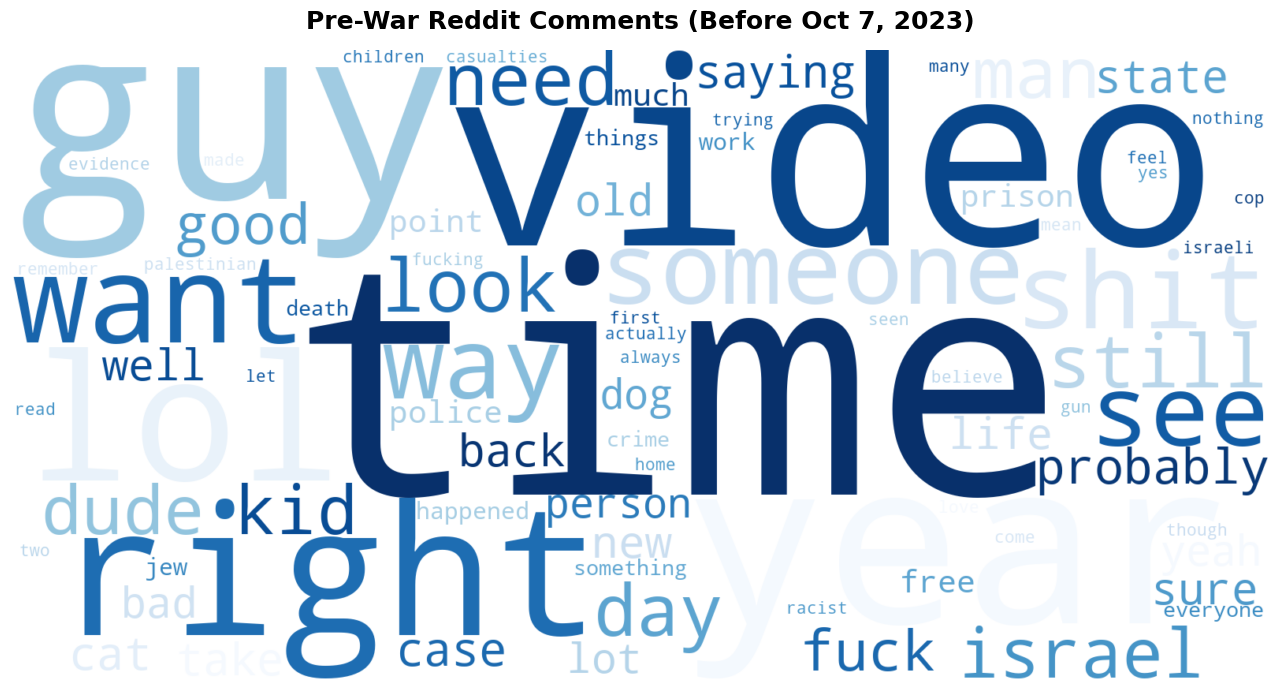

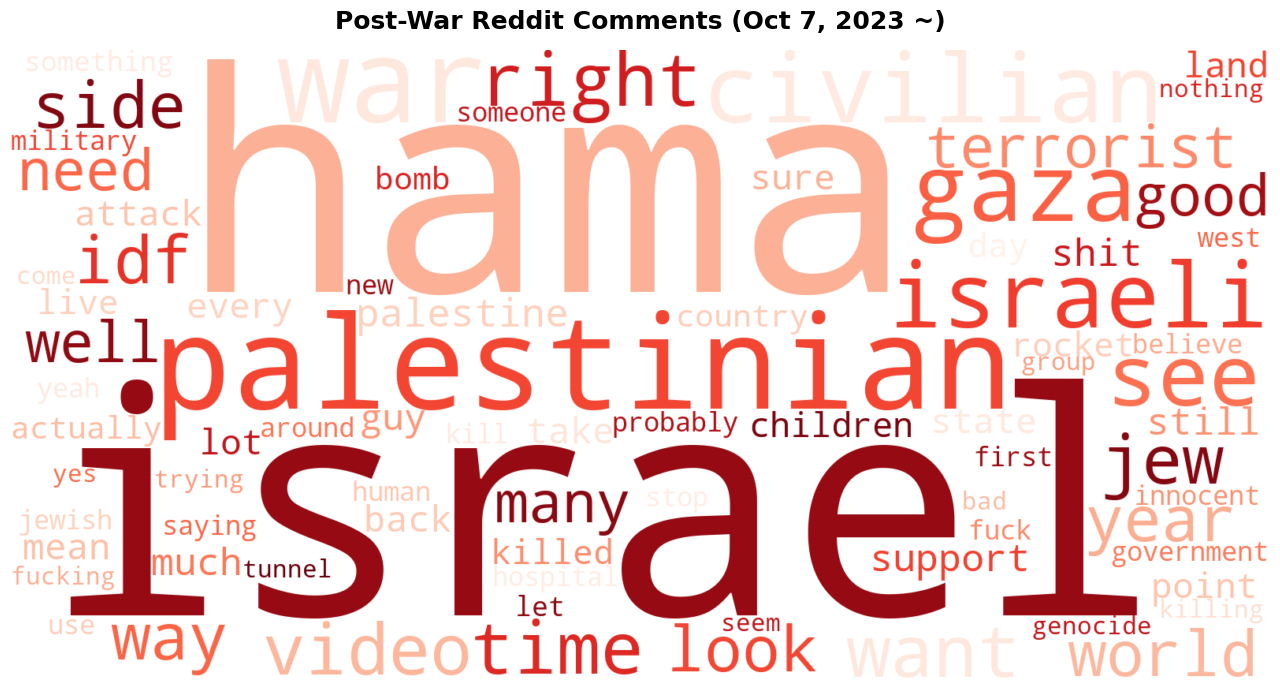

In [3]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def make_wordcloud(text, title, colormap):
    wc = WordCloud(
        width=1600, height=800,
        background_color='white',
        max_words=80,          # 단어 수 줄여서 큰 단어 더 크게
        colormap=colormap,
        collocations=False,
        prefer_horizontal=1.0  # 모두 가로로 배치해서 가독성 높임
    ).generate(text)
    
    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=18, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

# 전쟁 전: 파란 계열, 전쟁 후: 붉은 계열
make_wordcloud(pre_war_text,  'Pre-War Reddit Comments (Before Oct 7, 2023)',  'Blues')
make_wordcloud(post_war_text, 'Post-War Reddit Comments (Oct 7, 2023 ~)', 'Reds')